# 3A — BRUM Strict Augmentation 

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import os, gc, json, math, shutil, warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Mounted at /content/drive
Torch: 2.10.0+cpu
CUDA available: False


In [ ]:


PROJECT_ROOT = Path('/content/drive/MyDrive/ResearchProject')
ONE_CAR_ID = 'car_26004751'

DUST3R_ROOT_V5 = PROJECT_ROOT / 'dust3r_outputs_batch_strict_singlecar_method_v1'
CAR_DIR = DUST3R_ROOT_V5 / ONE_CAR_ID
PKG_PATH = CAR_DIR / 'brum_ready_scene.pt'

NOVEL_ROOT = CAR_DIR / 'novel_views_brum_strict_v7_slerp_depth'
NOVEL_IMG_DIR = NOVEL_ROOT / 'images'
NOVEL_MASK_DIR = NOVEL_ROOT / 'masks'
NOVEL_WEIGHT_DIR = NOVEL_ROOT / 'weights'
NOVEL_VIS_DIR = NOVEL_ROOT / 'visualizations'
NOVEL_DEBUG_DIR = NOVEL_ROOT / 'debug_arrays'

NOVEL_META = NOVEL_ROOT / 'novel_views_manifest.json'
NOVEL_BRUM_META = NOVEL_ROOT / 'novel_views_brum_manifest.json'
NOVEL_OBJECT_META = NOVEL_ROOT / 'novel_views_object_manifest.json'
NOVEL_CSV = NOVEL_ROOT / 'novel_view_summary.csv'
NOVEL_CONFIG = NOVEL_ROOT / 'augmentation_config_brum_strict_v7_slerp_depth.json'

VIEW_ORDER = [
    'front', 'front_left', 'side_left', 'rear_left',
    'rear', 'rear_right', 'side_right', 'front_right'
]

BRUM_W, BRUM_H = 512, 256
BRUM_K = np.array([[512., 0., 256.],
                   [0., 512., 128.],
                   [0.,   0.,   1.]], dtype=np.float32)

DUST3R_CONF_GAMMA = 1.5
MAX_INTERP_H_REAL = 0.08
H_VALUES = [0.025, 0.050, 0.075, 0.080]


POINTS_PER_PIXEL = 16
SPLAT_RADIUS_PX = 2
DEPTH_EPS = 1e-5
POSE_INTERPOLATION_MODE = 'translation_linear_rotation_slerp'
RENDERING_MODE = 'depth_aware_zbuffer_splatting'

MAX_SOURCE_POINTS = 300_000
MAX_FULL_CLOUD_POINTS = 400_000
OVERWRITE_NOVEL_OUTPUTS = True


BACKGROUND_WEIGHT_VALUE = 1.0
MIN_CONF_WEIGHT = 0.05
CONF_WEIGHT_GAMMA_FOR_SOFT_WEIGHT = 1.0

print('PKG_PATH:', PKG_PATH, 'exists=', PKG_PATH.exists())
print('NOVEL_ROOT:', NOVEL_ROOT)

PKG_PATH: /content/drive/MyDrive/ResearchProject/dust3r_outputs_batch_strict_singlecar_method_v1/car_26004751/brum_ready_scene.pt exists= True
NOVEL_ROOT: /content/drive/MyDrive/ResearchProject/dust3r_outputs_batch_strict_singlecar_method_v1/car_26004751/novel_views_brum_strict_v7_slerp_depth


# CREATE brum_ready_scene.pt 


In [ ]:

def _to_numpy_cpu(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def _invert_pose(T):
    T = np.asarray(T, dtype=np.float32)
    assert T.shape == (4, 4), f"Expected 4x4 pose, got {T.shape}"
    R = T[:3, :3]
    t = T[:3, 3]

    T_inv = np.eye(4, dtype=np.float32)
    T_inv[:3, :3] = R.T
    T_inv[:3, 3] = -R.T @ t
    return T_inv

def _project_to_rotation_matrix(R):
    U, _, Vt = np.linalg.svd(np.asarray(R, dtype=np.float64))
    R_proj = U @ Vt
    if np.linalg.det(R_proj) < 0:
        U[:, -1] *= -1
        R_proj = U @ Vt
    return R_proj

def _rotmat_to_quat_wxyz(R):
    R = _project_to_rotation_matrix(R)
    tr = np.trace(R)

    if tr > 0:
        S = np.sqrt(tr + 1.0) * 2.0
        w = 0.25 * S
        x = (R[2, 1] - R[1, 2]) / S
        y = (R[0, 2] - R[2, 0]) / S
        z = (R[1, 0] - R[0, 1]) / S
    else:
        idx = int(np.argmax(np.diag(R)))
        if idx == 0:
            S = np.sqrt(1.0 + R[0, 0] - R[1, 1] - R[2, 2]) * 2.0
            w = (R[2, 1] - R[1, 2]) / S
            x = 0.25 * S
            y = (R[0, 1] + R[1, 0]) / S
            z = (R[0, 2] + R[2, 0]) / S
        elif idx == 1:
            S = np.sqrt(1.0 + R[1, 1] - R[0, 0] - R[2, 2]) * 2.0
            w = (R[0, 2] - R[2, 0]) / S
            x = (R[0, 1] + R[1, 0]) / S
            y = 0.25 * S
            z = (R[1, 2] + R[2, 1]) / S
        else:
            S = np.sqrt(1.0 + R[2, 2] - R[0, 0] - R[1, 1]) * 2.0
            w = (R[1, 0] - R[0, 1]) / S
            x = (R[0, 2] + R[2, 0]) / S
            y = (R[1, 2] + R[2, 1]) / S
            z = 0.25 * S

    q = np.array([w, x, y, z], dtype=np.float64)
    return q / max(np.linalg.norm(q), 1e-12)

def _quat_wxyz_to_rotmat(q):
    q = np.asarray(q, dtype=np.float64)
    q = q / max(np.linalg.norm(q), 1e-12)
    w, x, y, z = q

    return np.array([
        [1 - 2*y*y - 2*z*z, 2*x*y - 2*z*w,     2*x*z + 2*y*w],
        [2*x*y + 2*z*w,     1 - 2*x*x - 2*z*z, 2*y*z - 2*x*w],
        [2*x*z - 2*y*w,     2*y*z + 2*x*w,     1 - 2*x*x - 2*y*y],
    ], dtype=np.float64)

def _slerp_quat_wxyz(q0, q1, t):
    q0 = q0 / max(np.linalg.norm(q0), 1e-12)
    q1 = q1 / max(np.linalg.norm(q1), 1e-12)

    dot = float(np.dot(q0, q1))
    if dot < 0.0:
        q1 = -q1
        dot = -dot

    dot = np.clip(dot, -1.0, 1.0)

    if dot > 0.9995:
        q = q0 + t * (q1 - q0)
        return q / max(np.linalg.norm(q), 1e-12)

    theta_0 = np.arccos(dot)
    theta = theta_0 * t

    s0 = np.cos(theta) - dot * np.sin(theta) / np.sin(theta_0)
    s1 = np.sin(theta) / np.sin(theta_0)

    q = s0 * q0 + s1 * q1
    return q / max(np.linalg.norm(q), 1e-12)

def _interpolate_pose_c2w(T0, T1, h):
    h = float(h)
    assert 0.0 <= h <= MAX_INTERP_H_REAL + 1e-9, f"h={h} exceeds {MAX_INTERP_H_REAL}"

    T0 = np.asarray(T0, dtype=np.float64)
    T1 = np.asarray(T1, dtype=np.float64)

    q0 = _rotmat_to_quat_wxyz(T0[:3, :3])
    q1 = _rotmat_to_quat_wxyz(T1[:3, :3])
    qh = _slerp_quat_wxyz(q0, q1, h)

    Tout = np.eye(4, dtype=np.float64)
    Tout[:3, :3] = _quat_wxyz_to_rotmat(qh)
    Tout[:3, 3] = (1.0 - h) * T0[:3, 3] + h * T1[:3, 3]

    return Tout.astype(np.float32)

def _build_adjacent_sampled_poses(T_c2w_list, views):
    sampled = {}
    n = len(T_c2w_list)

    for i in range(n):
        sampled[i] = []
        for j, direction in [((i - 1) % n, "prev"), ((i + 1) % n, "next")]:
            for h in H_VALUES:
                sampled[i].append({
                    "source_idx": int(i),
                    "source_view": str(views[i]),
                    "helper_idx": int(j),
                    "helper_view": str(views[j]),
                    "ring_direction": direction,
                    "h": float(h),
                    "T_c2w": _interpolate_pose_c2w(
                        T_c2w_list[i],
                        T_c2w_list[j],
                        h
                    ).astype(np.float32),
                })

    return sampled

def create_brum_ready_scene_if_missing():
    if PKG_PATH.exists():
        print("✅ brum_ready_scene.pt already exists:", PKG_PATH)
        return

    ga_path = CAR_DIR / "global_alignment.pt"
    xyz_path = CAR_DIR / "global_xyz_multiview.npy"
    manifest_path = CAR_DIR / "prepared_camera_manifest.csv"

    assert CAR_DIR.exists(), f"Missing car output folder: {CAR_DIR}"
    assert ga_path.exists(), f"Missing global alignment file: {ga_path}"
    assert xyz_path.exists(), f"Missing global xyz file: {xyz_path}"
    assert manifest_path.exists(), f"Missing prepared manifest: {manifest_path}"

    print("Creating missing BRUM-ready scene:")
    print("  from:", ga_path)
    print("  to:  ", PKG_PATH)

    ga = torch.load(ga_path, map_location="cpu", weights_only=False)
    df = pd.read_csv(manifest_path)

    df = df[df["view"].isin(VIEW_ORDER)].copy()
    df["view_index"] = df["view"].apply(lambda v: VIEW_ORDER.index(v))
    df = df.sort_values("view_index").reset_index(drop=True)

    assert df["view"].tolist() == VIEW_ORDER, (
        f"Prepared manifest view order mismatch:\n"
        f"got      = {df['view'].tolist()}\n"
        f"expected = {VIEW_ORDER}"
    )

    views = list(ga["views"])
    assert views == VIEW_ORDER, f"GA view order mismatch: got={views}, expected={VIEW_ORDER}"

    images = []
    masks = []
    image_paths = []
    mask_paths = []

    for _, row in df.iterrows():
        img_path = Path(row["prepared_path"])
        assert img_path.exists(), f"Missing prepared image: {img_path}"

        img = np.asarray(Image.open(img_path).convert("RGB"), dtype=np.uint8)
        assert img.shape[:2] == (BRUM_H, BRUM_W), f"Bad image shape: {img_path} {img.shape}"

        images.append(img)
        image_paths.append(str(img_path))

        mask_path = row.get("prepared_mask_path", None)

        if isinstance(mask_path, str) and mask_path and Path(mask_path).exists():
            m = np.asarray(Image.open(mask_path).convert("L"), dtype=np.uint8)
            m = ((m > 127).astype(np.uint8) * 255)
            mask_paths.append(str(mask_path))
        else:
            m = np.ones((BRUM_H, BRUM_W), dtype=np.uint8) * 255
            mask_paths.append(None)

        assert m.shape == (BRUM_H, BRUM_W), f"Bad mask shape for {row['view']}: {m.shape}"
        masks.append(m)

    T_c2w_list = [
        _to_numpy_cpu(T).astype(np.float32)
        for T in ga["poses"]
    ]

    pts3d = [
        _to_numpy_cpu(p).astype(np.float32)
        for p in ga["pts3d"]
    ]

    if ga.get("confs", None) is not None:
        confs = [
            _to_numpy_cpu(c).astype(np.float32)
            for c in ga["confs"]
        ]
    else:
        confs = []
        for p in pts3d:
            confs.append(np.ones(p.shape[:2], dtype=np.float32) * 999.0)

    for i, v in enumerate(views):
        assert T_c2w_list[i].shape == (4, 4), f"{v}: bad pose shape {T_c2w_list[i].shape}"
        assert pts3d[i].shape[:2] == (BRUM_H, BRUM_W), f"{v}: bad pts3d shape {pts3d[i].shape}"
        assert confs[i].shape[:2] == (BRUM_H, BRUM_W), f"{v}: bad conf shape {confs[i].shape}"
        assert np.isfinite(T_c2w_list[i]).all(), f"{v}: non-finite pose"
        assert np.isfinite(pts3d[i]).all(), f"{v}: non-finite pts3d"

    global_xyz = np.load(xyz_path).astype(np.float32)

    pkg = {
        "views": views,
        "images": images,
        "image_paths": image_paths,
        "mask_paths": mask_paths,
        "masks": masks,

        "poses_c2w": T_c2w_list,
        "P_list": [_invert_pose(T).astype(np.float32) for T in T_c2w_list],

        "K_list": [BRUM_K.copy() for _ in T_c2w_list],
        "shared_K": BRUM_K.copy(),
        "image_sizes_wh": [(BRUM_W, BRUM_H) for _ in T_c2w_list],

        "pts3d": pts3d,
        "confs": confs,
        "global_xyz_multiview": global_xyz,

        "sampled_poses": _build_adjacent_sampled_poses(T_c2w_list, views),

        "brum_real_confidence_gamma": float(DUST3R_CONF_GAMMA),
        "brum_max_real_h": float(MAX_INTERP_H_REAL),
        "brum_canvas_wh": (BRUM_W, BRUM_H),
        "background_supervision": "real images filtered by segmentation mask; generated views use masked weighted supervision",
        "created_by": "3A fallback brum_ready_scene.pt creator",
    }

    torch.save(pkg, PKG_PATH)
    torch.save(pkg, CAR_DIR / "scene_package.pt")

    print("✅ Saved:", PKG_PATH)
    print("✅ Saved:", CAR_DIR / "scene_package.pt")

create_brum_ready_scene_if_missing()

✅ brum_ready_scene.pt already exists: /content/drive/MyDrive/ResearchProject/dust3r_outputs_batch_strict_singlecar_method_v1/car_26004751/brum_ready_scene.pt


In [ ]:
# ============================================================
# 2. Fail-fast path checker
# ============================================================
def assert_strict_paths():
    expected = 'dust3r_outputs_batch_strict_singlecar_method_v1'
    for p in [DUST3R_ROOT_V5, CAR_DIR, PKG_PATH, NOVEL_ROOT]:
        ps = str(p)
        assert expected in ps, f"STALE/FOREIGN ROOT: {ps}"
    assert PKG_PATH.exists(), f"Missing 2B v5 package: {PKG_PATH}"
    assert not any(s in str(NOVEL_ROOT) for s in [
        'corrected_v2', 'all_cars', 'paper_equivalent', 'refined_supervision_SMOKE'
    ]), f"Unsafe old augmentation folder: {NOVEL_ROOT}"
    print('✅ strict v5 input paths and v6 output path are clean')

assert_strict_paths()

✅ strict v5 input paths and v6 output path are clean


# 3. Utility functions


In [ ]:
def to_numpy_any(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    if isinstance(x, list):
        return [to_numpy_any(v) for v in x]
    if isinstance(x, tuple):
        return tuple(to_numpy_any(v) for v in x)
    return np.asarray(x)

def ensure_uint8_rgb(img):
    arr = to_numpy_any(img)
    if arr.ndim == 2:
        arr = np.repeat(arr[..., None], 3, axis=-1)
    if arr.shape[-1] == 4:
        arr = arr[..., :3]
    if arr.dtype != np.uint8:
        arr = arr.astype(np.float32)
        if arr.size and arr.max() <= 1.0:
            arr = arr * 255.0
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    return arr

def ensure_mask_u8(mask):
    m = to_numpy_any(mask)
    if m.ndim == 3:
        m = m[..., 0]
    return ((m > 0).astype(np.uint8) * 255)

def resize_rgb_to_hw(img, hw):
    H, W = hw
    return np.asarray(Image.fromarray(ensure_uint8_rgb(img)).resize((W, H), Image.BILINEAR))

def resize_mask_to_hw(mask, hw):
    H, W = hw
    return np.asarray(Image.fromarray(ensure_mask_u8(mask)).resize((W, H), Image.NEAREST))

def save_u8_gray(path, arr):
    a = np.asarray(arr)
    if a.dtype != np.uint8:
        a = np.nan_to_num(a.astype(np.float32), nan=0.0, posinf=1.0, neginf=0.0)
        if a.size and a.max() <= 1.0 + 1e-6:
            a = a * 255.0
        a = np.clip(a, 0, 255).astype(np.uint8)
    Image.fromarray(a).save(path)

def normalize01(a):
    a = np.nan_to_num(np.asarray(a, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    mx = float(a.max()) if a.size else 0.0
    if mx <= 1e-8:
        return np.zeros_like(a, dtype=np.float32)
    return np.clip(a / mx, 0, 1).astype(np.float32)

def to_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if torch.is_tensor(obj):
        return obj.detach().cpu().tolist()
    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    if isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    if isinstance(obj, Path):
        return str(obj)
    raise TypeError(type(obj))

def invert_pose(T):
    T = np.asarray(T, dtype=np.float64)
    assert T.shape == (4, 4), T.shape
    R = T[:3, :3]
    t = T[:3, 3]
    out = np.eye(4, dtype=np.float64)
    out[:3, :3] = R.T
    out[:3, 3] = -R.T @ t
    return out.astype(np.float32)

def project_to_rotation_matrix(Rm):
    U, _, Vt = np.linalg.svd(np.asarray(Rm, dtype=np.float64))
    Rproj = U @ Vt
    if np.linalg.det(Rproj) < 0:
        U[:, -1] *= -1
        Rproj = U @ Vt
    return Rproj

def normalize_quat(q):
    q = np.asarray(q, dtype=np.float64)
    return q / max(np.linalg.norm(q), 1e-12)

def rotmat_to_quat_wxyz(Rm):
    Rm = project_to_rotation_matrix(Rm)
    tr = float(np.trace(Rm))
    if tr > 0:
        S = np.sqrt(tr + 1.0) * 2.0
        w = 0.25 * S
        x = (Rm[2,1] - Rm[1,2]) / S
        y = (Rm[0,2] - Rm[2,0]) / S
        z = (Rm[1,0] - Rm[0,1]) / S
    else:
        i = int(np.argmax(np.diag(Rm)))
        if i == 0:
            S = np.sqrt(1.0 + Rm[0,0] - Rm[1,1] - Rm[2,2]) * 2.0
            w = (Rm[2,1] - Rm[1,2]) / S
            x = 0.25 * S
            y = (Rm[0,1] + Rm[1,0]) / S
            z = (Rm[0,2] + Rm[2,0]) / S
        elif i == 1:
            S = np.sqrt(1.0 + Rm[1,1] - Rm[0,0] - Rm[2,2]) * 2.0
            w = (Rm[0,2] - Rm[2,0]) / S
            x = (Rm[0,1] + Rm[1,0]) / S
            y = 0.25 * S
            z = (Rm[1,2] + Rm[2,1]) / S
        else:
            S = np.sqrt(1.0 + Rm[2,2] - Rm[0,0] - Rm[1,1]) * 2.0
            w = (Rm[1,0] - Rm[0,1]) / S
            x = (Rm[0,2] + Rm[2,0]) / S
            y = (Rm[1,2] + Rm[2,1]) / S
            z = 0.25 * S
    return normalize_quat(np.array([w, x, y, z], dtype=np.float64))

def quat_wxyz_to_rotmat(q):
    w, x, y, z = normalize_quat(q)
    return np.array([
        [1 - 2*y*y - 2*z*z, 2*x*y - 2*z*w,     2*x*z + 2*y*w],
        [2*x*y + 2*z*w,     1 - 2*x*x - 2*z*z, 2*y*z - 2*x*w],
        [2*x*z - 2*y*w,     2*y*z + 2*x*w,     1 - 2*x*x - 2*y*y],
    ], dtype=np.float64)

def slerp_quat_wxyz(q0, q1, h):
    q0 = normalize_quat(q0)
    q1 = normalize_quat(q1)
    dot = float(np.dot(q0, q1))
    if dot < 0:
        q1 = -q1
        dot = -dot
    dot = float(np.clip(dot, -1.0, 1.0))
    if dot > 0.9995:
        return normalize_quat(q0 + h * (q1 - q0))
    theta0 = np.arccos(dot)
    theta = theta0 * h
    sin_theta0 = np.sin(theta0)
    s0 = np.cos(theta) - dot * np.sin(theta) / sin_theta0
    s1 = np.sin(theta) / sin_theta0
    return normalize_quat(s0 * q0 + s1 * q1)

def interpolate_pose_c2w(T0, T1, h):
    h = float(h)
    assert 0.0 <= h <= MAX_INTERP_H_REAL + 1e-9, f"h={h} exceeds BRUM real-scene max {MAX_INTERP_H_REAL}"
    T0 = np.asarray(T0, dtype=np.float64)
    T1 = np.asarray(T1, dtype=np.float64)
    out = np.eye(4, dtype=np.float64)
    q = slerp_quat_wxyz(rotmat_to_quat_wxyz(T0[:3,:3]), rotmat_to_quat_wxyz(T1[:3,:3]), h)
    out[:3, :3] = quat_wxyz_to_rotmat(q)
    out[:3, 3] = (1.0 - h) * T0[:3, 3] + h * T1[:3, 3]
    return out.astype(np.float32)

def project_world_to_image(X_world, T_c2w, K):
    X = np.asarray(X_world, dtype=np.float32)
    T_w2c = invert_pose(T_c2w).astype(np.float32)
    Xc = X @ T_w2c[:3, :3].T + T_w2c[:3, 3][None, :]
    z = Xc[:, 2]
    valid = z > 1e-6
    uv_h = Xc @ np.asarray(K, dtype=np.float32).T
    uv = np.empty((len(X), 2), dtype=np.float32)
    denom = np.maximum(uv_h[:, 2], 1e-6)
    uv[:, 0] = uv_h[:, 0] / denom
    uv[:, 1] = uv_h[:, 1] / denom
    valid = valid & np.isfinite(uv).all(axis=1)
    return uv, z.astype(np.float32), valid

def subsample_cloud_np(X, colors=None, conf=None, max_points=300_000, seed=0):
    if len(X) <= max_points:
        return X, colors, conf
    idx = np.random.default_rng(seed).choice(len(X), size=max_points, replace=False)
    return X[idx], (colors[idx] if colors is not None else None), (conf[idx] if conf is not None else None)

In [ ]:

pkg = torch.load(PKG_PATH, map_location='cpu', weights_only=False)
print('Loaded:', PKG_PATH)
print('Top-level keys:', sorted(pkg.keys()))

required_keys = ['views', 'images', 'poses_c2w', 'K_list', 'pts3d', 'masks', 'confs']
missing = [k for k in required_keys if k not in pkg]
if missing:
    raise KeyError(f"Missing required 2B v5 keys: {missing}. Available keys: {sorted(pkg.keys())}")

views = list(pkg['views'])
images = [ensure_uint8_rgb(x) for x in pkg['images']]
T_c2w_list = np.stack([to_numpy_any(x) for x in pkg['poses_c2w']]).astype(np.float64)
Ks = np.stack([to_numpy_any(x) for x in pkg['K_list']]).astype(np.float32)
PTS3D_LIST = [to_numpy_any(x).astype(np.float32) for x in pkg['pts3d']]
MASK_LIST = [ensure_mask_u8(x) for x in pkg['masks']]
CONF_LIST = [to_numpy_any(x).astype(np.float32) for x in pkg['confs']]

print('views:', views)
print('n images:', len(images), 'image0 shape:', images[0].shape)
print('poses:', T_c2w_list.shape)
print('K:', Ks.shape, Ks[0])
print('pts3d[0]:', PTS3D_LIST[0].shape, 'mask[0]:', MASK_LIST[0].shape, 'conf[0]:', CONF_LIST[0].shape)

Loaded: /content/drive/MyDrive/ResearchProject/dust3r_outputs_batch_strict_singlecar_method_v1/car_26004751/brum_ready_scene.pt
Top-level keys: ['K_list', 'P_list', 'background_supervision', 'brum_canvas_wh', 'brum_max_real_h', 'brum_real_confidence_gamma', 'confs', 'created_by', 'global_xyz_multiview', 'image_paths', 'image_sizes_wh', 'images', 'mask_paths', 'masks', 'poses_c2w', 'pts3d', 'sampled_poses', 'shared_K', 'views']
views: ['front', 'front_left', 'side_left', 'rear_left', 'rear', 'rear_right', 'side_right', 'front_right']
n images: 8 image0 shape: (256, 512, 3)
poses: (8, 4, 4)
K: (8, 3, 3) [[512.   0. 256.]
 [  0. 512. 128.]
 [  0.   0.   1.]]
pts3d[0]: (256, 512, 3) mask[0]: (256, 512) conf[0]: (256, 512)


In [ ]:
def assert_loaded_scene_is_brum_strict():
    assert views == VIEW_ORDER, f"View order mismatch. got={views}, expected={VIEW_ORDER}"
    assert len(images) == 8 and len(T_c2w_list) == 8 and len(Ks) == 8
    for i, v in enumerate(views):
        img = images[i]
        H, W = img.shape[:2]
        assert (W, H) == (BRUM_W, BRUM_H), f"{v}: image is {W}x{H}, expected 512x256"
        assert PTS3D_LIST[i].shape[:2] == (BRUM_H, BRUM_W), f"{v}: pts3d shape {PTS3D_LIST[i].shape}"
        assert CONF_LIST[i].shape[:2] == (BRUM_H, BRUM_W), f"{v}: conf shape {CONF_LIST[i].shape}"
        if MASK_LIST[i].shape[:2] != (BRUM_H, BRUM_W):
            raise AssertionError(f"{v}: mask shape {MASK_LIST[i].shape}, expected 256x512")
        assert np.allclose(Ks[i], BRUM_K, atol=1e-4), f"{v}: K differs from hardcoded BRUM_K: {Ks[i]}"
        assert np.isfinite(T_c2w_list[i]).all(), f"{v}: non-finite pose"
        assert np.isfinite(PTS3D_LIST[i]).all(), f"{v}: non-finite pts3d"
    print('✅ loaded 2B scene is strict BRUM: 8 views, 512x256, fixed shared K, no intrinsic scaling')

assert_loaded_scene_is_brum_strict()

✅ loaded 2B scene is strict BRUM: 8 views, 512x256, fixed shared K, no intrinsic scaling



# 6. Visual input checker from 2B package

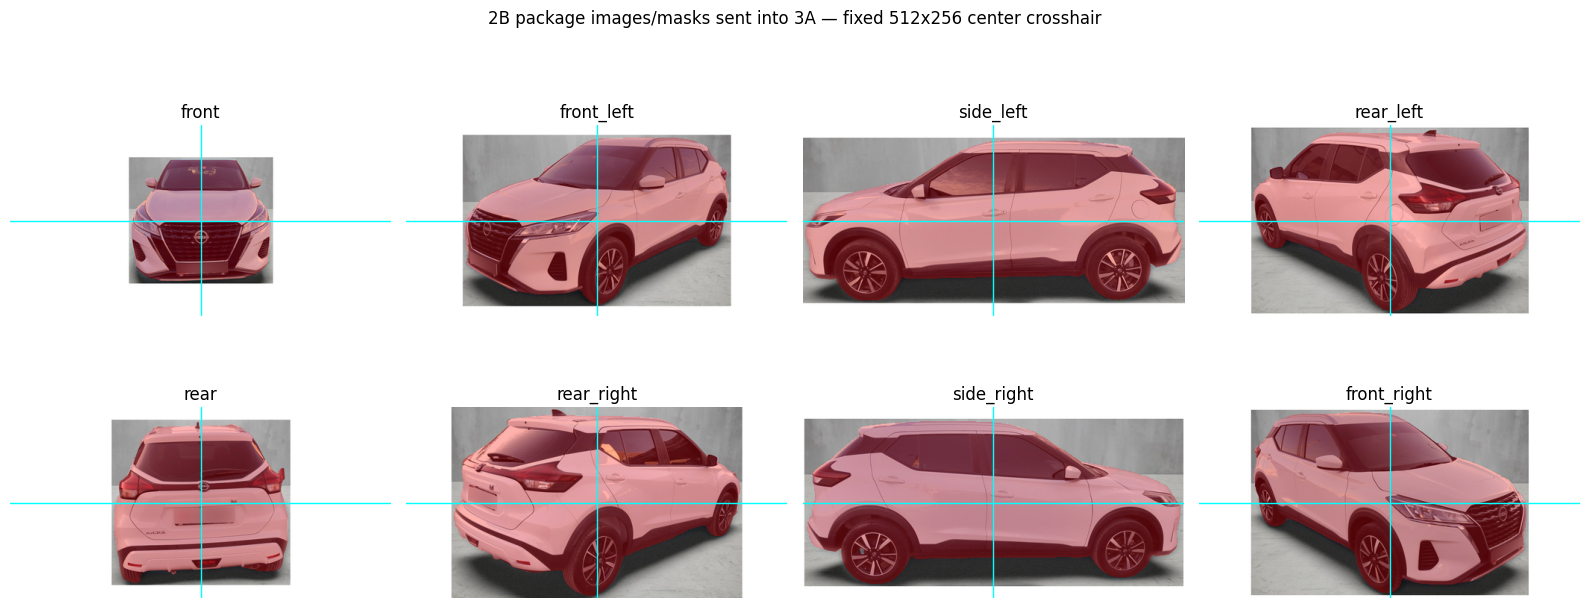

In [ ]:

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, v, img, m in zip(axes.ravel(), views, images, MASK_LIST):
    overlay = img.copy()
    red = np.zeros_like(overlay); red[..., 0] = 255
    mb = m > 0
    overlay[mb] = (0.70 * overlay[mb] + 0.30 * red[mb]).astype(np.uint8)
    ax.imshow(overlay)
    ax.axvline(BRUM_W/2, color='cyan', linewidth=1)
    ax.axhline(BRUM_H/2, color='cyan', linewidth=1)
    ax.set_title(v)
    ax.axis('off')
plt.suptitle('2B package images/masks sent into 3A — fixed 512x256 center crosshair')
plt.tight_layout()
plt.show()


# 7. Build BRUM-confidence-filtered full world cloud

In [ ]:

full_xyz_chunks = []
full_conf_chunks = []
per_view_rows = []

for i, v in enumerate(views):
    pts = PTS3D_LIST[i]
    conf = CONF_LIST[i]
    mask = MASK_LIST[i] > 0
    keep = np.isfinite(pts).all(axis=-1) & np.isfinite(conf) & (conf >= DUST3R_CONF_GAMMA) & mask
    xyz = pts[keep].reshape(-1, 3).astype(np.float32)
    cc = conf[keep].reshape(-1).astype(np.float32)
    full_xyz_chunks.append(xyz)
    full_conf_chunks.append(cc)
    per_view_rows.append({
        'view': v,
        'kept_points_conf_masked': int(len(xyz)),
        'mask_fg_frac': float(mask.mean()),
        'conf_ge_1p5_frac': float((conf >= DUST3R_CONF_GAMMA).mean()),
    })

df_cloud = pd.DataFrame(per_view_rows)
display(df_cloud)
assert (df_cloud['kept_points_conf_masked'] > 1000).all(), 'Too few confidence+mask points in at least one view.'

FULL_WORLD_CLOUD = np.concatenate(full_xyz_chunks, axis=0).astype(np.float32)
FULL_WORLD_CONF = np.concatenate(full_conf_chunks, axis=0).astype(np.float32)
assert len(FULL_WORLD_CLOUD) > 10_000, len(FULL_WORLD_CLOUD)
print('FULL_WORLD_CLOUD:', FULL_WORLD_CLOUD.shape)
print('conf min/mean/max:', float(FULL_WORLD_CONF.min()), float(FULL_WORLD_CONF.mean()), float(FULL_WORLD_CONF.max()))

,view,kept_points_conf_masked,mask_fg_frac,conf_ge_1p5_frac
0,front,14823,0.194107,0.113380
1,front_left,37129,0.412636,0.422073
2,side_left,42137,0.600662,0.379074
3,rear_left,42846,0.461182,0.475563
4,rear,31949,0.302742,0.249313
5,rear_right,44878,0.486618,0.492653
6,side_right,45937,0.597984,0.415565
7,front_right,43129,0.462280,0.460426


FULL_WORLD_CLOUD: (302828, 3)
conf min/mean/max: 1.500016450881958 2.1792352199554443 2.905485153198242



# 8. Prepare local adjacent BRUM interpolation poses

In [ ]:

def make_adjacent_ring_samples():
    samples = {}
    n = len(T_c2w_list)

    for i in range(n):
        samples[i] = []

        prev_idx = (i - 1) % n
        next_idx = (i + 1) % n

        for j, direction in [(prev_idx, 'prev'), (next_idx, 'next')]:
            for h in H_VALUES:
                T = interpolate_pose_c2w(T_c2w_list[i], T_c2w_list[j], h)
                samples[i].append({
                    'source_idx': int(i),
                    'source_view': str(views[i]),
                    'helper_idx': int(j),
                    'helper_view': str(views[j]),
                    'ring_direction': direction,
                    'h': float(h),
                    'T_c2w': T.astype(np.float32),
                    'pose_interpolation': POSE_INTERPOLATION_MODE,
                })

    return samples

sampled_poses = make_adjacent_ring_samples()
n_samples = sum(len(v) for v in sampled_poses.values())
print('BRUM local adjacent interpolated poses:', n_samples)
print('Pose interpolation:', POSE_INTERPOLATION_MODE)
for i in range(len(views)):
    hs = sorted(set(round(float(s['h']), 3) for s in sampled_poses[i]))
    helpers = sorted(set((s['helper_idx'], s['helper_view'], s['ring_direction'])
                     for s in sampled_poses[i]))
    print(i, views[i], 'n=', len(sampled_poses[i]), 'h=', hs, 'neighbors=', helpers)

assert n_samples == 8 * 2 * len(H_VALUES)
assert all(float(s['h']) <= MAX_INTERP_H_REAL for arr in sampled_poses.values() for s in arr)

BRUM local adjacent interpolated poses: 64
Pose interpolation: translation_linear_rotation_slerp
0 front n= 8 h= [0.025, 0.05, 0.075, 0.08] neighbors= [(1, 'front_left', 'next'), (7, 'front_right', 'prev')]
1 front_left n= 8 h= [0.025, 0.05, 0.075, 0.08] neighbors= [(0, 'front', 'prev'), (2, 'side_left', 'next')]
2 side_left n= 8 h= [0.025, 0.05, 0.075, 0.08] neighbors= [(1, 'front_left', 'prev'), (3, 'rear_left', 'next')]
3 rear_left n= 8 h= [0.025, 0.05, 0.075, 0.08] neighbors= [(2, 'side_left', 'prev'), (4, 'rear', 'next')]
4 rear n= 8 h= [0.025, 0.05, 0.075, 0.08] neighbors= [(3, 'rear_left', 'prev'), (5, 'rear_right', 'next')]
5 rear_right n= 8 h= [0.025, 0.05, 0.075, 0.08] neighbors= [(4, 'rear', 'prev'), (6, 'side_right', 'next')]
6 side_right n= 8 h= [0.025, 0.05, 0.075, 0.08] neighbors= [(5, 'rear_right', 'prev'), (7, 'front_right', 'next')]
7 front_right n= 8 h= [0.025, 0.05, 0.075, 0.08] neighbors= [(0, 'front', 'next'), (6, 'side_right', 'prev')]


# 9. Depth-aware z-buffer splatter renderer


In [ ]:
def _make_splat_offsets_weighted(radius_px):
    r = int(radius_px)
    offsets = []
    for dy in range(-r, r + 1):
        for dx in range(-r, r + 1):
            d2 = dx * dx + dy * dy
            if d2 <= r * r:
                # Smooth, deterministic kernel. The exact kernel is less important than the z-buffer.
                w = np.exp(-d2 / max(2.0 * r * r, 1e-6))
                offsets.append((dx, dy, float(w)))
    return offsets

_OFFSETS_WEIGHTED_CACHE = {}

def get_offsets_weighted(radius_px):
    key = int(radius_px)
    if key not in _OFFSETS_WEIGHTED_CACHE:
        _OFFSETS_WEIGHTED_CACHE[key] = _make_splat_offsets_weighted(radius_px)
    return _OFFSETS_WEIGHTED_CACHE[key]


def build_splat_candidates(uv, z, image_size, radius_px=SPLAT_RADIUS_PX):
    """
    Expand each projected point to a small disk of candidate output pixels.

    Returns flattened output pixel indices, original point indices, candidate depths,
    and splat kernel weights.
    """
    H, W = image_size
    uv = np.asarray(uv, dtype=np.float32)
    z = np.asarray(z, dtype=np.float32)

    if len(uv) == 0:
        return None, None, None, None

    base_x = np.round(uv[:, 0]).astype(np.int32)
    base_y = np.round(uv[:, 1]).astype(np.int32)
    point_ids = np.arange(len(uv), dtype=np.int64)

    pix_all, point_all, z_all, kernel_all = [], [], [], []

    for dx, dy, kw in get_offsets_weighted(radius_px):
        x = base_x + dx
        y = base_y + dy
        inside = (
            (x >= 0) & (x < W) &
            (y >= 0) & (y < H) &
            np.isfinite(z) & (z > 1e-6)
        )
        if not np.any(inside):
            continue
        pix = y[inside].astype(np.int64) * int(W) + x[inside].astype(np.int64)
        pix_all.append(pix)
        point_all.append(point_ids[inside])
        z_all.append(z[inside].astype(np.float32))
        kernel_all.append(np.full(int(inside.sum()), kw, dtype=np.float32))

    if not pix_all:
        return None, None, None, None

    return (
        np.concatenate(pix_all),
        np.concatenate(point_all),
        np.concatenate(z_all),
        np.concatenate(kernel_all),
    )


def zbuffer_keep_nearest(pix_idx, z_cand, image_size, depth_eps=DEPTH_EPS):
    """
    Compute a z-buffer and return a boolean mask selecting candidates on the nearest layer.
    """
    H, W = image_size
    n_pix = int(H) * int(W)
    depth = np.full(n_pix, np.inf, dtype=np.float32)

    # For repeated pixel indices, keep the minimum depth.
    np.minimum.at(depth, pix_idx, z_cand)

    keep = np.isfinite(depth[pix_idx]) & (z_cand <= depth[pix_idx] + float(depth_eps))
    return depth, keep


def splat_rgb_depthaware(uv, z, colors, image_size, radius_px=SPLAT_RADIUS_PX, depth_eps=DEPTH_EPS):
    """
    Depth-aware RGB splatting.

    Returns:
        rgb_uint8: rendered image
        mask_uint8: pixels with visible projected support
        weight_float: visible splat support / density
        depth_float: z-buffer depth image, inf where empty
    """
    H, W = image_size
    colors = np.asarray(colors, dtype=np.float32)
    if colors.size and colors.max() > 1.0:
        colors = colors / 255.0

    pix_idx, point_idx, z_cand, kernel = build_splat_candidates(uv, z, image_size, radius_px=radius_px)
    if pix_idx is None:
        return (
            np.zeros((H, W, 3), dtype=np.uint8),
            np.zeros((H, W), dtype=np.uint8),
            np.zeros((H, W), dtype=np.float32),
            np.full((H, W), np.inf, dtype=np.float32),
        )

    depth, keep = zbuffer_keep_nearest(pix_idx, z_cand, image_size, depth_eps=depth_eps)
    pix_k = pix_idx[keep]
    point_k = point_idx[keep]
    w_k = kernel[keep]

    accum = np.zeros((H * W, 3), dtype=np.float32)
    weight = np.zeros(H * W, dtype=np.float32)

    np.add.at(accum, pix_k, colors[point_k] * w_k[:, None])
    np.add.at(weight, pix_k, w_k)

    valid = weight > 1e-8
    out = np.zeros((H * W, 3), dtype=np.float32)
    out[valid] = accum[valid] / weight[valid, None]

    rgb = np.clip(out.reshape(H, W, 3) * 255.0, 0, 255).astype(np.uint8)
    mask = (valid.reshape(H, W).astype(np.uint8) * 255)
    return rgb, mask, weight.reshape(H, W).astype(np.float32), depth.reshape(H, W).astype(np.float32)


def splat_scalar_depthaware(uv, z, scalar, image_size, radius_px=SPLAT_RADIUS_PX, depth_eps=DEPTH_EPS):
    """
    Depth-aware scalar splatting used for confidence projection.
    """
    H, W = image_size
    values = np.asarray(scalar, dtype=np.float32).reshape(-1)

    pix_idx, point_idx, z_cand, kernel = build_splat_candidates(uv, z, image_size, radius_px=radius_px)
    if pix_idx is None:
        return np.zeros((H, W), dtype=np.float32)

    depth, keep = zbuffer_keep_nearest(pix_idx, z_cand, image_size, depth_eps=depth_eps)
    pix_k = pix_idx[keep]
    point_k = point_idx[keep]
    w_k = kernel[keep]

    accum = np.zeros(H * W, dtype=np.float32)
    weight = np.zeros(H * W, dtype=np.float32)

    np.add.at(accum, pix_k, values[point_k] * w_k)
    np.add.at(weight, pix_k, w_k)

    valid = weight > 1e-8
    out = np.zeros(H * W, dtype=np.float32)
    out[valid] = accum[valid] / weight[valid]
    return out.reshape(H, W).astype(np.float32)


def render_full_cloud_mask_depthaware(T_c2w, K, image_size, full_cloud):
    """
    Project fused DUSt3R world cloud into a novel camera, then z-buffer it.

    This output is a projected occupancy/support map, not the raw 3D point cloud.
    """
    H, W = image_size
    uv, z, valid = project_world_to_image(full_cloud, T_c2w, K)
    inside = (
        valid &
        (uv[:, 0] >= 0) & (uv[:, 0] < W) &
        (uv[:, 1] >= 0) & (uv[:, 1] < H) &
        np.isfinite(z) & (z > 1e-6)
    )
    if int(inside.sum()) == 0:
        return (
            np.zeros((H, W), dtype=np.uint8),
            np.zeros((H, W), dtype=np.float32),
            np.full((H, W), np.inf, dtype=np.float32),
            0,
        )

    ones_rgb = np.ones((int(inside.sum()), 3), dtype=np.float32)
    _, mask, density, depth = splat_rgb_depthaware(
        uv[inside], z[inside], ones_rgb, image_size,
        radius_px=SPLAT_RADIUS_PX, depth_eps=DEPTH_EPS,
    )
    return mask, density, depth, int(inside.sum())

# Backwards-compatible names are kept intentionally.
def splat_rgb(uv, z, colors, image_size):
    rgb, mask, weight, _depth = splat_rgb_depthaware(uv, z, colors, image_size)
    return rgb, mask, weight

def splat_scalar(uv, z, scalar, image_size):
    return splat_scalar_depthaware(uv, z, scalar, image_size)

def render_full_cloud_mask(T_c2w, K, image_size, full_cloud):
    mask, density, _depth, n_inside = render_full_cloud_mask_depthaware(T_c2w, K, image_size, full_cloud)
    return mask, density, n_inside

print('Renderer ready:', RENDERING_MODE)
print('  splat_radius_px =', SPLAT_RADIUS_PX)
print('  depth_eps       =', DEPTH_EPS)
print('  points_per_pixel parameter retained for metadata =', POINTS_PER_PIXEL)


Renderer ready: depth_aware_zbuffer_splatting
  splat_radius_px = 2
  depth_eps       = 1e-05
  points_per_pixel parameter retained for metadata = 16


# Per-source BRUM cloud preparation — fixed K only

In [ ]:

def prepare_view_pointcloud(source_idx):
    source_idx = int(source_idx)
    pts = PTS3D_LIST[source_idx]
    conf = CONF_LIST[source_idx]
    mask = MASK_LIST[source_idx] > 0
    img = images[source_idx]

    assert img.shape[:2] == (BRUM_H, BRUM_W)
    assert pts.shape[:2] == (BRUM_H, BRUM_W)
    assert conf.shape[:2] == (BRUM_H, BRUM_W)
    assert np.allclose(Ks[source_idx], BRUM_K, atol=1e-4), 'K scaling/recompute detected; forbidden.'

    X = pts.reshape(-1, 3)
    C = img.reshape(-1, 3)
    F = conf.reshape(-1)
    M = mask.reshape(-1)

    keep = np.isfinite(X).all(axis=1) & np.isfinite(F) & (F >= DUST3R_CONF_GAMMA) & M
    if int(keep.sum()) < 1000:
        raise RuntimeError(f"Too few valid BRUM source points for {source_idx} {views[source_idx]}: {int(keep.sum())}")

    return X[keep].astype(np.float32), C[keep].astype(np.uint8), F[keep].astype(np.float32), BRUM_K.copy(), (BRUM_H, BRUM_W)

def render_full_cloud_mask(T_c2w, K, image_size, full_cloud):
    H, W = image_size
    uv, z, valid = project_world_to_image(full_cloud, T_c2w, K)
    inside = valid & (uv[:,0] >= 0) & (uv[:,0] < W) & (uv[:,1] >= 0) & (uv[:,1] < H)
    if int(inside.sum()) == 0:
        return np.zeros((H, W), dtype=np.uint8), np.zeros((H, W), dtype=np.float32), 0
    ones = np.ones(int(inside.sum()), dtype=np.float32)
    weight = splat_scalar(uv[inside], z[inside], ones, image_size)
    return (weight > 0).astype(np.uint8) * 255, weight, int(inside.sum())

def conf_to_soft_weight(conf_projected):
    c = np.nan_to_num(np.asarray(conf_projected, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    c_norm = np.clip(c / max(float(DUST3R_CONF_GAMMA), 1e-6), 0, 1) ** float(CONF_WEIGHT_GAMMA_FOR_SOFT_WEIGHT)
    # But keep zero where no projected source exists.
    c_norm[c <= 0] = 0.0
    positive = c_norm > 0
    c_norm[positive] = np.maximum(c_norm[positive], float(MIN_CONF_WEIGHT))
    return c_norm.astype(np.float32)

def build_brum_training_weight_map(weight_raw, source_mask, full_mask, source_conf_projected):
    src = np.asarray(source_mask) > 0
    full = np.asarray(full_mask) > 0

    xnor = src == full
    inconsistent = np.logical_xor(src, full)
    and_support = src & full
    background_agreement = (~src) & (~full)

    w = normalize01(weight_raw) * conf_to_soft_weight(source_conf_projected)

    # Eq. 6: keep only XNOR valid pixels.
    w[~xnor] = 0.0

    # BRUM-critical: retain true background supervision.
    w[background_agreement] = float(BACKGROUND_WEIGHT_VALUE)

    train_mask = (xnor.astype(np.uint8) * 255)

    return np.clip(w, 0, 1).astype(np.float32), {
        'xnor_mask': train_mask,
        'inconsistent_mask': inconsistent.astype(np.uint8) * 255,
        'and_support_mask': and_support.astype(np.uint8) * 255,
        'background_agreement_mask': background_agreement.astype(np.uint8) * 255,
        'train_mask': train_mask,
    }


# 11. Generate BRUM synthetic views

In [ ]:

if OVERWRITE_NOVEL_OUTPUTS and NOVEL_ROOT.exists():
    shutil.rmtree(NOVEL_ROOT)

for d in [NOVEL_IMG_DIR, NOVEL_MASK_DIR, NOVEL_WEIGHT_DIR, NOVEL_VIS_DIR, NOVEL_DEBUG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

FULL_WORLD_CLOUD_FAST, _, _ = subsample_cloud_np(FULL_WORLD_CLOUD, None, None, MAX_FULL_CLOUD_POINTS, seed=12345)
print('FULL_WORLD_CLOUD original:', len(FULL_WORLD_CLOUD), 'used for full mask:', len(FULL_WORLD_CLOUD_FAST))

records = []
rows = []
counter = 0

for source_idx, samples in sampled_poses.items():
    X_world, colors, conf_values, K, render_hw = prepare_view_pointcloud(source_idx)
    X_world, colors, conf_values = subsample_cloud_np(
        X_world, colors, conf_values,
        max_points=MAX_SOURCE_POINTS,
        seed=1000 + int(source_idx)
    )
    H, W = render_hw
    print(f"\nSource {source_idx:02d} {views[source_idx]}: {len(X_world):,} source points, {len(samples)} target poses")

    for sample in samples:
        counter += 1
        helper_idx = int(sample['helper_idx'])
        h = float(sample['h'])
        T_novel_c2w = np.asarray(sample['T_c2w'], dtype=np.float32)
        assert h <= MAX_INTERP_H_REAL + 1e-9
        assert np.allclose(K, BRUM_K, atol=1e-4)

        uv, z, valid = project_world_to_image(X_world, T_novel_c2w, K)
        inside = valid & (uv[:,0] >= 0) & (uv[:,0] < W) & (uv[:,1] >= 0) & (uv[:,1] < H)
        n_inside = int(inside.sum())
        if n_inside <= 0:
            print('WARNING: no inside source points', source_idx, helper_idx, h)
            continue

        rgb_clean, source_proj_mask, raw_density, source_depth = splat_rgb_depthaware(
            uv[inside], z[inside], colors[inside], render_hw,
            radius_px=SPLAT_RADIUS_PX, depth_eps=DEPTH_EPS
        )
        conf_projected = splat_scalar_depthaware(
            uv[inside], z[inside], conf_values[inside], render_hw,
            radius_px=SPLAT_RADIUS_PX, depth_eps=DEPTH_EPS
        )

        full_mask, full_density, full_depth, n_full_inside = render_full_cloud_mask_depthaware(
            T_novel_c2w, K, render_hw, FULL_WORLD_CLOUD_FAST
        )

        train_weight, mask_dict = build_brum_training_weight_map(
            raw_density, source_proj_mask, full_mask, conf_projected
        )
        background_agreement = mask_dict['background_agreement_mask'] > 0
        inconsistent = mask_dict['inconsistent_mask'] > 0

        rgb_clean[background_agreement] = 0
        rgb_clean[inconsistent] = 0
        train_mask = mask_dict['train_mask']

        base = f"src{source_idx:02d}_to{helper_idx:02d}_{sample['ring_direction']}_h{int(round(h*1000)):03d}"

        clean_img_path = NOVEL_IMG_DIR / f'{base}__clean_rgb.png'
        train_img_path = NOVEL_IMG_DIR / f'{base}.png'
        train_mask_path = NOVEL_MASK_DIR / f'{base}__train_mask.png'
        xnor_mask_path = NOVEL_MASK_DIR / f'{base}__xnor_mask.png'
        inconsistent_mask_path = NOVEL_MASK_DIR / f'{base}__inconsistent_mask.png'
        and_support_mask_path = NOVEL_MASK_DIR / f'{base}__and_support_mask.png'
        background_mask_path = NOVEL_MASK_DIR / f'{base}__background_agreement_mask.png'
        source_mask_path = NOVEL_MASK_DIR / f'{base}__source_projected_mask.png'
        full_mask_path = NOVEL_MASK_DIR / f'{base}__full_cloud_mask.png'
        weight_path = NOVEL_WEIGHT_DIR / f'{base}__weight.png'
        conf_weight_path = NOVEL_WEIGHT_DIR / f'{base}__conf_projected.png'
        raw_density_path = NOVEL_WEIGHT_DIR / f'{base}__raw_density.png'
        source_depth_path = NOVEL_DEBUG_DIR / f'{base}__source_depth.npy'
        full_depth_path = NOVEL_DEBUG_DIR / f'{base}__full_depth.npy'
        source_depth_vis_path = NOVEL_WEIGHT_DIR / f'{base}__source_depth_vis.png'
        full_depth_vis_path = NOVEL_WEIGHT_DIR / f'{base}__full_depth_vis.png'

        # image_path is the generated RGB target. 4B must multiply loss by train_weight/train_mask.
        Image.fromarray(rgb_clean).save(clean_img_path)
        Image.fromarray(rgb_clean).save(train_img_path)
        Image.fromarray(train_mask).save(train_mask_path)
        Image.fromarray(mask_dict['xnor_mask']).save(xnor_mask_path)
        Image.fromarray(mask_dict['inconsistent_mask']).save(inconsistent_mask_path)
        Image.fromarray(mask_dict['and_support_mask']).save(and_support_mask_path)
        Image.fromarray(mask_dict['background_agreement_mask']).save(background_mask_path)
        Image.fromarray(source_proj_mask).save(source_mask_path)
        Image.fromarray(full_mask).save(full_mask_path)
        save_u8_gray(weight_path, train_weight)
        save_u8_gray(conf_weight_path, normalize01(conf_projected))
        save_u8_gray(raw_density_path, normalize01(raw_density))
        np.save(source_depth_path, source_depth)
        np.save(full_depth_path, full_depth)
        source_depth_vis = np.where(np.isfinite(source_depth), source_depth, 0.0)
        full_depth_vis = np.where(np.isfinite(full_depth), full_depth, 0.0)
        source_depth_vis = normalize01(np.where(source_depth_vis > 0, 1.0 / np.maximum(source_depth_vis, 1e-6), 0.0))
        full_depth_vis = normalize01(np.where(full_depth_vis > 0, 1.0 / np.maximum(full_depth_vis, 1e-6), 0.0))
        save_u8_gray(source_depth_vis_path, source_depth_vis)
        save_u8_gray(full_depth_vis_path, full_depth_vis)

        rec = {
            'schema_version': 'BRUM_STRICT_AUGMENTATION_V7_SLERP_DEPTH',
            'car_id': ONE_CAR_ID,
            'source_idx': int(source_idx),
            'source_view': str(views[source_idx]),
            'helper_idx': int(helper_idx),
            'helper_view': str(sample['helper_view']),
            'ring_direction': str(sample['ring_direction']),
            'h': float(h),
            'T_c2w': T_novel_c2w.astype(float).tolist(),
            'P_w2c': invert_pose(T_novel_c2w).astype(float).tolist(),
            'K': BRUM_K.astype(float).tolist(),
            'render_size': [int(H), int(W)],
            'image_path': str(train_img_path),
            'clean_image_path': str(clean_img_path),
            'train_mask_path': str(train_mask_path),
            'xnor_mask_path': str(xnor_mask_path),
            'and_mask_path': str(and_support_mask_path),
            'inconsistent_mask_path': str(inconsistent_mask_path),
            'background_agreement_mask_path': str(background_mask_path),
            'source_mask_path': str(source_mask_path),
            'full_mask_path': str(full_mask_path),
            'weight_path': str(weight_path),
            'train_weight_path': str(weight_path),
            'conf_weight_path': str(conf_weight_path),
            'raw_density_path': str(raw_density_path),
            'source_depth_path': str(source_depth_path),
            'full_depth_path': str(full_depth_path),
            'source_depth_vis_path': str(source_depth_vis_path),
            'full_depth_vis_path': str(full_depth_vis_path),
            'n_source_points_used': int(len(X_world)),
            'n_projected_points_inside': int(n_inside),
            'n_full_cloud_points_inside': int(n_full_inside),
            'n_mask_pixels_train': int((train_mask > 0).sum()),
            'n_mask_pixels_xnor': int((mask_dict['xnor_mask'] > 0).sum()),
            'n_mask_pixels_and_support': int((mask_dict['and_support_mask'] > 0).sum()),
            'n_mask_pixels_excluded_xor': int((mask_dict['inconsistent_mask'] > 0).sum()),
            'train_mask_frac': float((train_mask > 0).mean()),
            'train_weight_frac': float((train_weight > 0).mean()),
            'mean_train_weight_positive': float(train_weight[train_weight > 0].mean()) if (train_weight > 0).any() else 0.0,
            'dust3r_confidence_gamma': float(DUST3R_CONF_GAMMA),
            'max_real_h': float(MAX_INTERP_H_REAL),
            'points_per_pixel': int(POINTS_PER_PIXEL),
            'splat_radius_px': int(SPLAT_RADIUS_PX),
            'background_weight_value': float(BACKGROUND_WEIGHT_VALUE),
            'generated_loss_policy_for_4B': 'masked_weighted_L1_only_no_generated_SSIM',
            'pose_interpolation': str(sample.get('pose_interpolation', POSE_INTERPOLATION_MODE)),
            'rendering_mode': RENDERING_MODE,
            'depth_eps': float(DEPTH_EPS),
            'paper_alignment_note': 'BRUM-style local DUSt3R pose interpolation with SLERP rotation interpolation, gamma confidence filtering, XNOR support check, depth-aware z-buffer splatting, normalized confidence/density weights.',
        }
        records.append(rec)
        rows.append({
            'source_view': views[source_idx],
            'helper_view': sample['helper_view'],
            'direction': sample['ring_direction'],
            'h': h,
            'inside_source_points': n_inside,
            'inside_full_points': n_full_inside,
            'train_mask_frac': rec['train_mask_frac'],
            'train_weight_frac': rec['train_weight_frac'],
            'mean_train_weight_positive': rec['mean_train_weight_positive'],
        })

        if counter % 8 == 0:
            print(f"  generated {counter}/{n_samples}: last={base}, weight_frac={rec['train_weight_frac']:.3f}")

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

assert len(records) > 0, 'No BRUM generated views created.'

for path in [NOVEL_META, NOVEL_BRUM_META, NOVEL_OBJECT_META]:
    path.write_text(json.dumps(records, indent=2, default=to_serializable))

df_novel = pd.DataFrame(rows)
df_novel.to_csv(NOVEL_CSV, index=False)

config = {
    'schema_version': 'BRUM_STRICT_AUGMENTATION_V7_SLERP_DEPTH',
    'input_package': str(PKG_PATH),
    'output_root': str(NOVEL_ROOT),
    'K': BRUM_K.tolist(),
    'canvas_wh': [BRUM_W, BRUM_H],
    'dust3r_confidence_gamma': DUST3R_CONF_GAMMA,
    'max_real_h': MAX_INTERP_H_REAL,
    'h_values': H_VALUES,
    'points_per_pixel': POINTS_PER_PIXEL,
    'splat_radius_px': SPLAT_RADIUS_PX,
    'pose_interpolation': POSE_INTERPOLATION_MODE,
    'rendering_mode': RENDERING_MODE,
    'depth_eps': DEPTH_EPS,
    'background_weight_value': BACKGROUND_WEIGHT_VALUE,
    'generated_loss_policy_for_4B': 'masked_weighted_L1_only_no_generated_SSIM',
}
NOVEL_CONFIG.write_text(json.dumps(config, indent=2))

print('\nSaved:', NOVEL_META)
print('Generated records:', len(records))
print('Pose interpolation:', POSE_INTERPOLATION_MODE)
print('Rendering:', RENDERING_MODE)
display(df_novel.head())
display(df_novel.describe(include='all'))

FULL_WORLD_CLOUD original: 302828 used for full mask: 302828

Source 00 front: 14,823 source points, 8 target poses
  generated 8/64: last=src00_to01_next_h080, weight_frac=0.895

Source 01 front_left: 37,129 source points, 8 target poses
  generated 16/64: last=src01_to02_next_h080, weight_frac=0.848

Source 02 side_left: 42,137 source points, 8 target poses
  generated 24/64: last=src02_to03_next_h080, weight_frac=0.721

Source 03 rear_left: 42,846 source points, 8 target poses
  generated 32/64: last=src03_to04_next_h080, weight_frac=0.872

Source 04 rear: 31,949 source points, 8 target poses
  generated 40/64: last=src04_to05_next_h080, weight_frac=0.958

Source 05 rear_right: 44,878 source points, 8 target poses
  generated 48/64: last=src05_to06_next_h080, weight_frac=0.834

Source 06 side_right: 45,937 source points, 8 target poses
  generated 56/64: last=src06_to07_next_h080, weight_frac=0.746

Source 07 front_right: 43,129 source points, 8 target poses
  generated 64/64: last=

,source_view,helper_view,direction,h,inside_source_points,inside_full_points,train_mask_frac,train_weight_frac,mean_train_weight_positive
0,front,front_right,prev,0.025,14823,302828,0.900864,0.900864,0.818976
1,front,front_right,prev,0.050,14823,302828,0.899498,0.899498,0.815281
2,front,front_right,prev,0.075,14823,302828,0.897827,0.897827,0.817208
3,front,front_right,prev,0.080,14823,302828,0.897514,0.897514,0.810471
4,front,front_left,next,0.025,14823,302828,0.900047,0.900047,0.820406


,source_view,helper_view,direction,h,inside_source_points,inside_full_points,train_mask_frac,train_weight_frac,mean_train_weight_positive
count,64,64,64,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000
unique,8,8,2,NaN,NaN,NaN,NaN,NaN,NaN
top,front,front_right,prev,NaN,NaN,NaN,NaN,NaN,NaN
freq,8,8,32,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,0.057500,37101.359375,289412.046875,0.843802,0.843802,0.599061
std,NaN,NaN,NaN,0.022111,9329.515761,23295.844524,0.072425,0.072425,0.117919
min,NaN,NaN,NaN,0.025000,14823.000000,243494.000000,0.711624,0.711624,0.433004
25%,NaN,NaN,NaN,0.043750,35831.000000,290217.000000,0.815134,0.815134,0.506986
50%,NaN,NaN,NaN,0.062500,41001.500000,302743.000000,0.855042,0.855042,0.585186
75%,NaN,NaN,NaN,0.076250,42879.750000,302828.000000,0.877710,0.877710,0.664606


checker

In [ ]:

records = json.loads(NOVEL_META.read_text())
assert len(records) == 8 * 2 * len(H_VALUES), f"Expected {8*2*len(H_VALUES)} generated views, got {len(records)}"

bad = []
for i, r in enumerate(records):
    reasons = []
    for key in [
        'image_path', 'clean_image_path', 'train_mask_path', 'weight_path',
        'source_mask_path', 'full_mask_path', 'inconsistent_mask_path'
    ]:
        if not Path(r[key]).exists():
            reasons.append(f"missing {key}")
    img = np.asarray(Image.open(r['clean_image_path']).convert('RGB'))
    mask = np.asarray(Image.open(r['train_mask_path']).convert('L'))
    weight = np.asarray(Image.open(r['weight_path']).convert('L'))

    if img.shape[:2] != (BRUM_H, BRUM_W):
        reasons.append(f"bad image shape {img.shape}")
    if mask.shape != (BRUM_H, BRUM_W):
        reasons.append(f"bad mask shape {mask.shape}")
    if weight.shape != (BRUM_H, BRUM_W):
        reasons.append(f"bad weight shape {weight.shape}")
    if not np.allclose(np.asarray(r['K'], dtype=np.float32), BRUM_K, atol=1e-4):
        reasons.append('K not BRUM_K')
    if float(r['h']) > MAX_INTERP_H_REAL + 1e-9:
        reasons.append('h too large')
    if r['generated_loss_policy_for_4B'] != 'masked_weighted_L1_only_no_generated_SSIM':
        reasons.append('wrong generated loss policy')
    if float(r['train_weight_frac']) <= 0.20:
        reasons.append(f"too little retained BRUM XNOR supervision={r['train_weight_frac']:.4f}")
    if int(r['n_projected_points_inside']) <= 500:
        reasons.append('too few projected source points')
    if int(r['n_full_cloud_points_inside']) <= 500:
        reasons.append('too few full cloud points')

    if reasons:
        bad.append((i, r['source_view'], r['helper_view'], r['h'], reasons))

print('records:', len(records))
if bad:
    print('BAD RECORDS:')
    for b in bad[:20]:
        print(b)
    raise AssertionError(f'{len(bad)} generated records failed strict checks')

print('✅ all generated BRUM records pass strict 4B compatibility checks')
print('manifest:', NOVEL_META)
print('config:', NOVEL_CONFIG)

records: 64
✅ all generated BRUM records pass strict 4B compatibility checks
manifest: /content/drive/MyDrive/ResearchProject/dust3r_outputs_batch_strict_singlecar_method_v1/car_26004751/novel_views_brum_strict_v7_slerp_depth/novel_views_manifest.json
config: /content/drive/MyDrive/ResearchProject/dust3r_outputs_batch_strict_singlecar_method_v1/car_26004751/novel_views_brum_strict_v7_slerp_depth/augmentation_config_brum_strict_v7_slerp_depth.json



# Visual diagnostics: generated RGB / masks / weights / depth

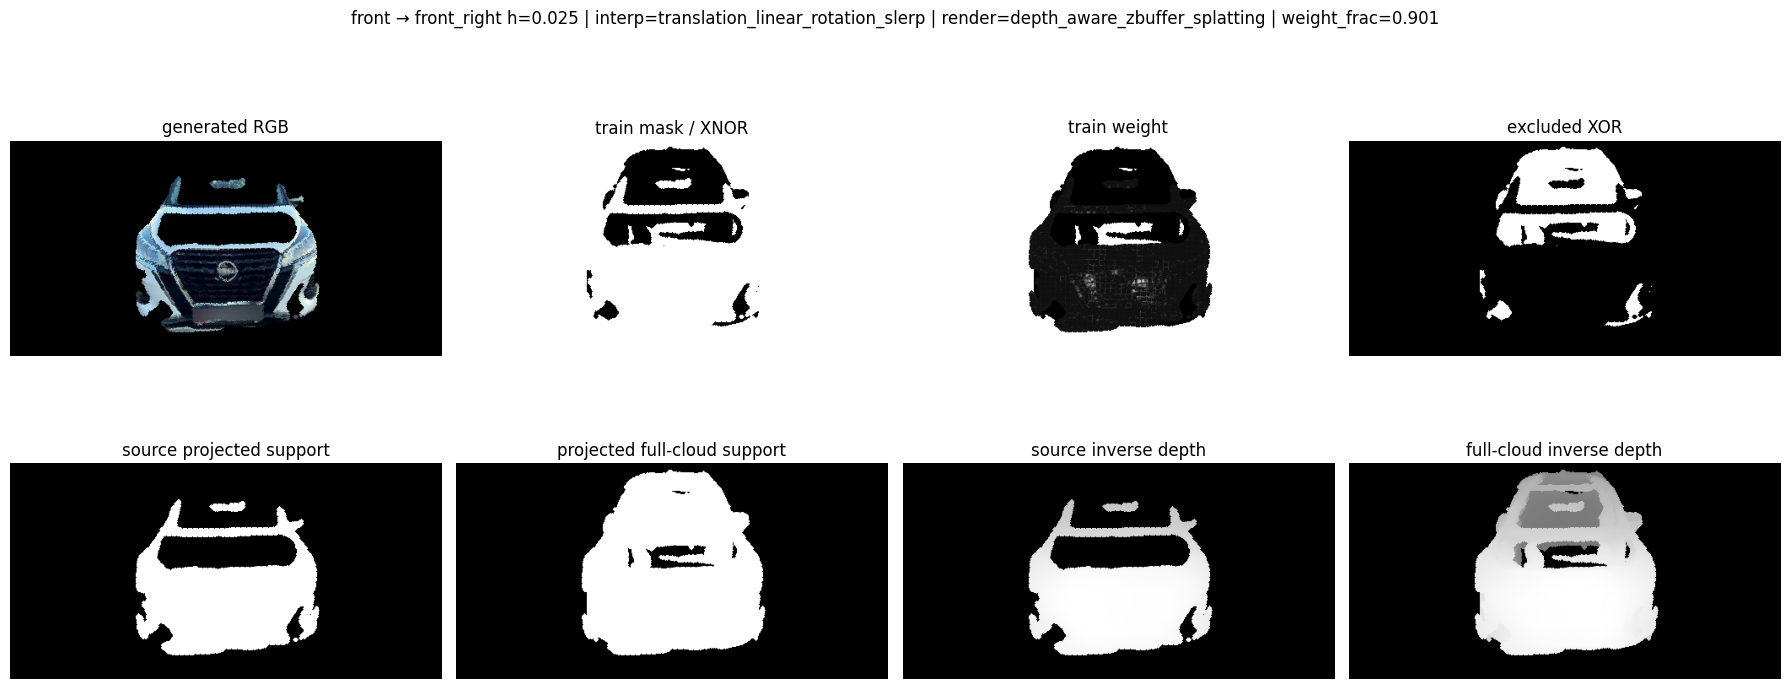

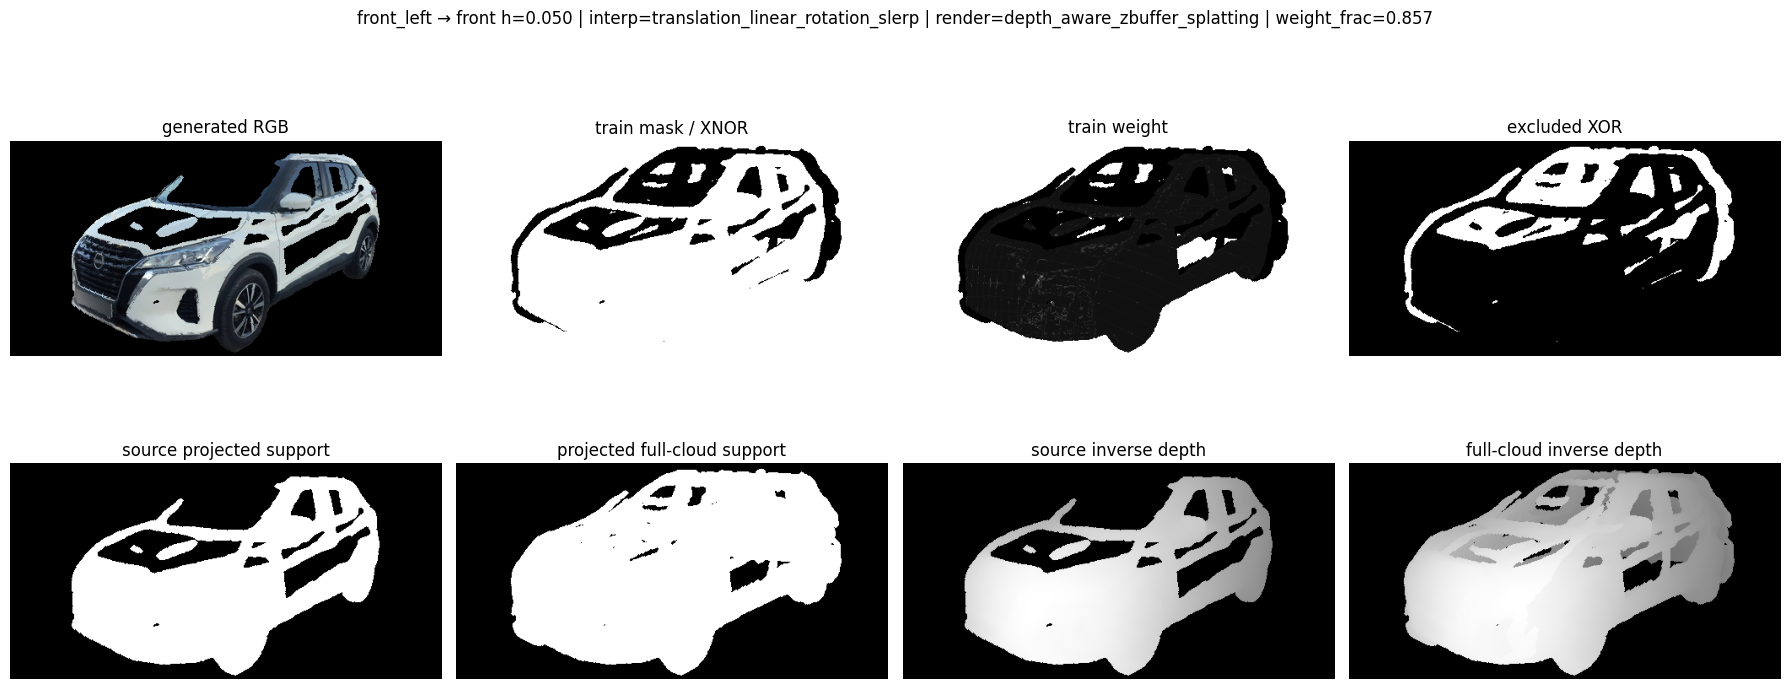

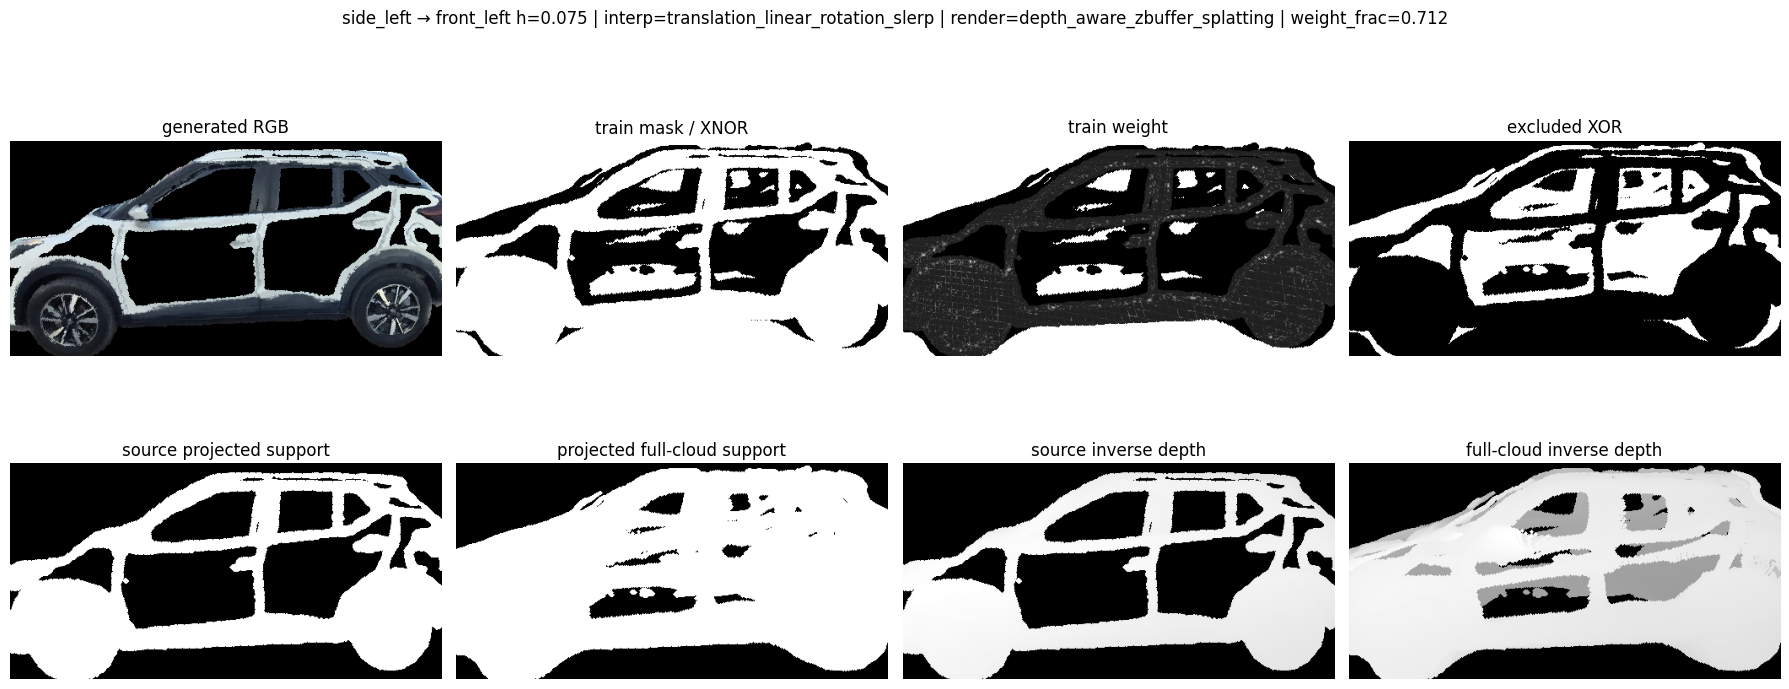

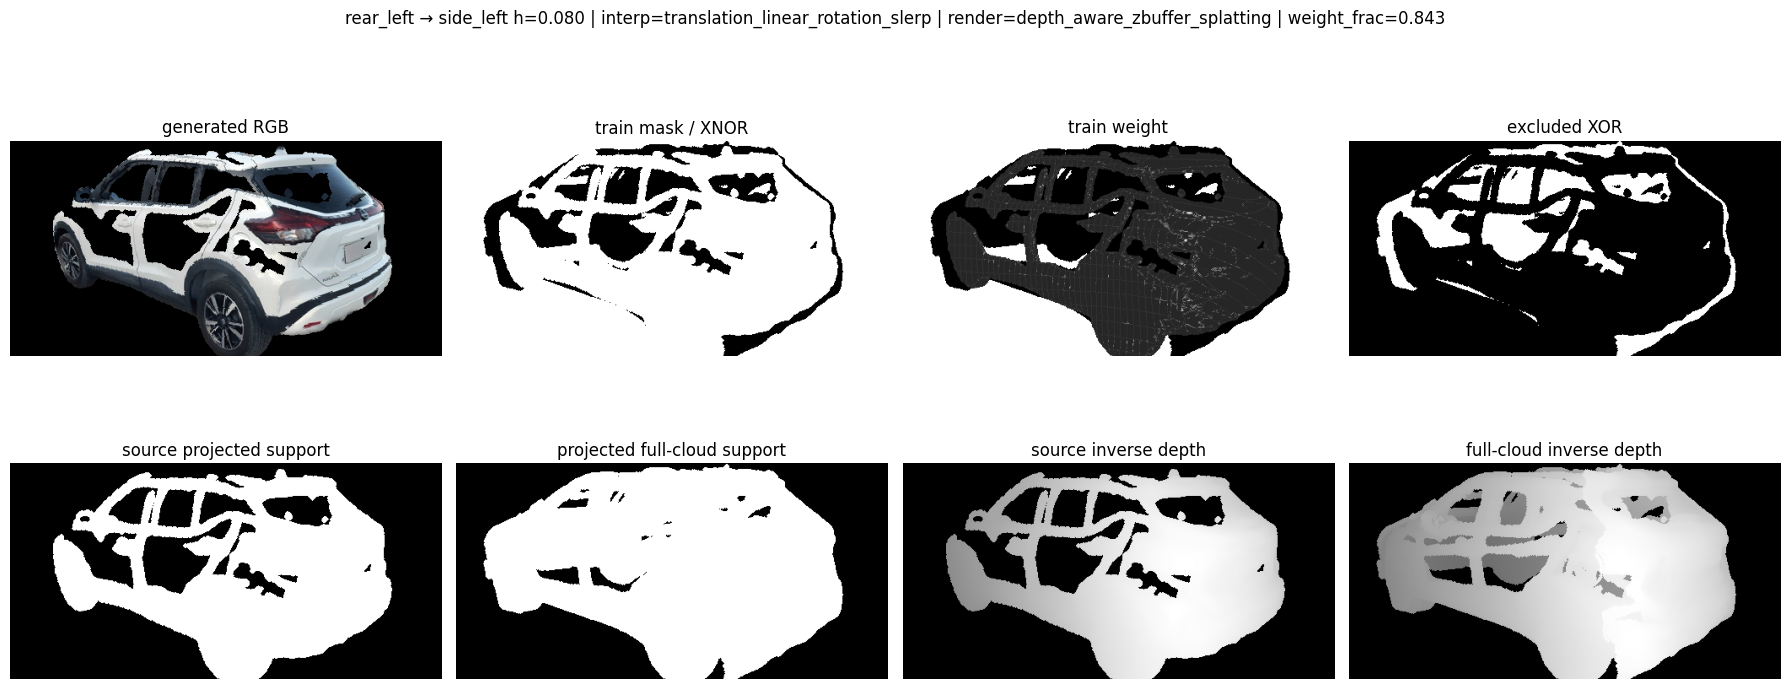

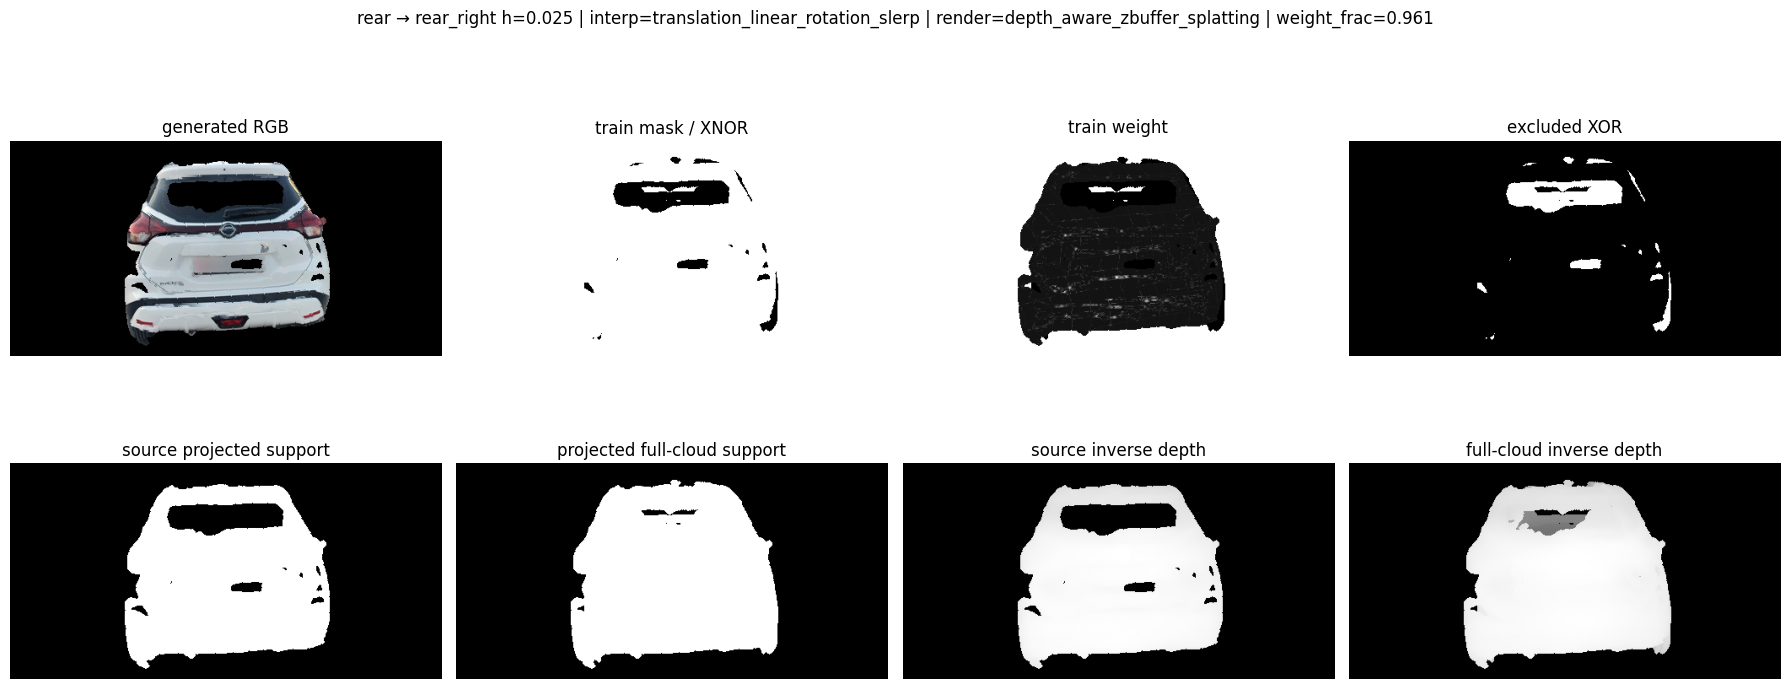

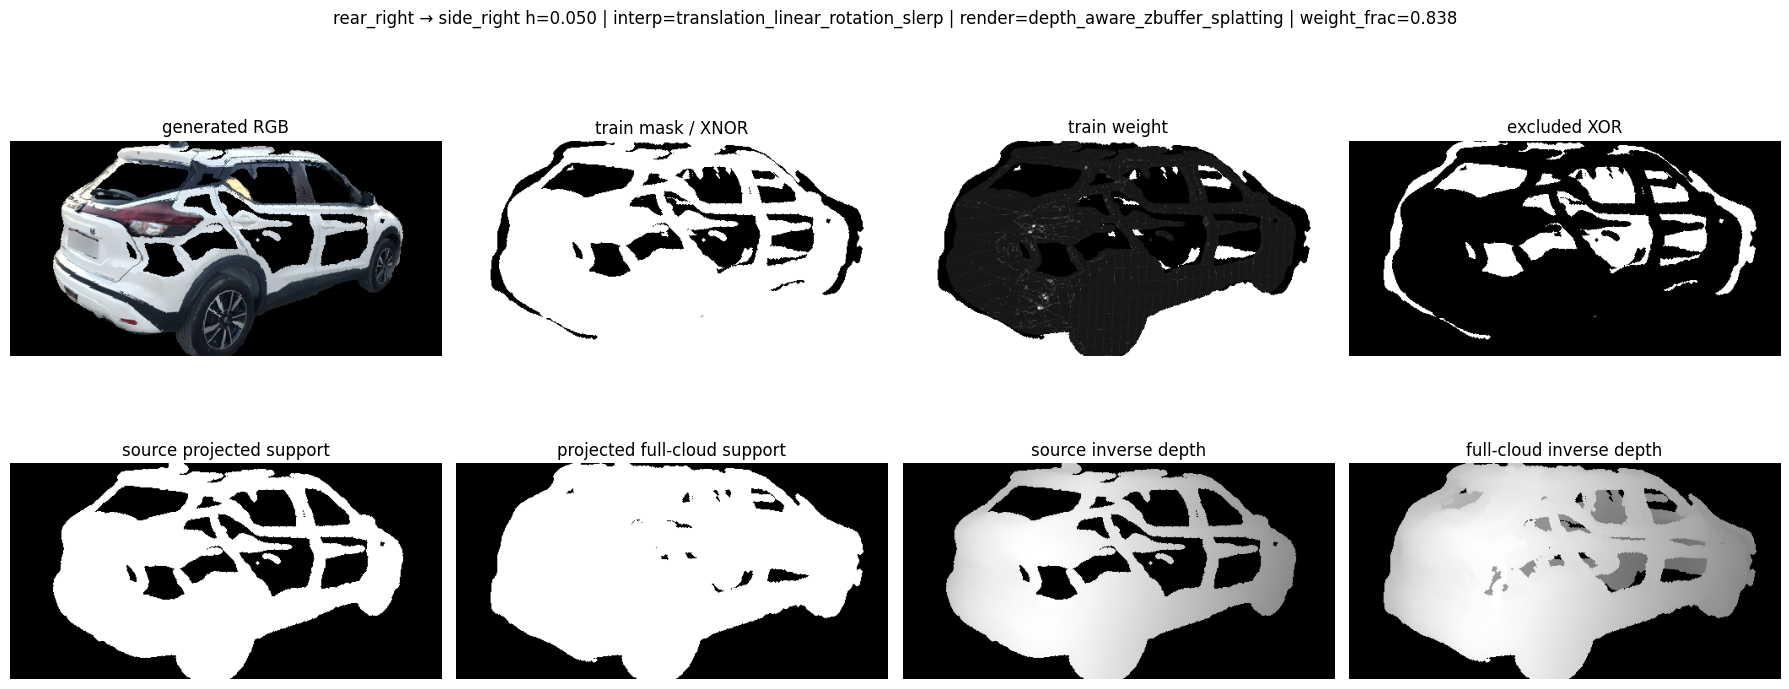

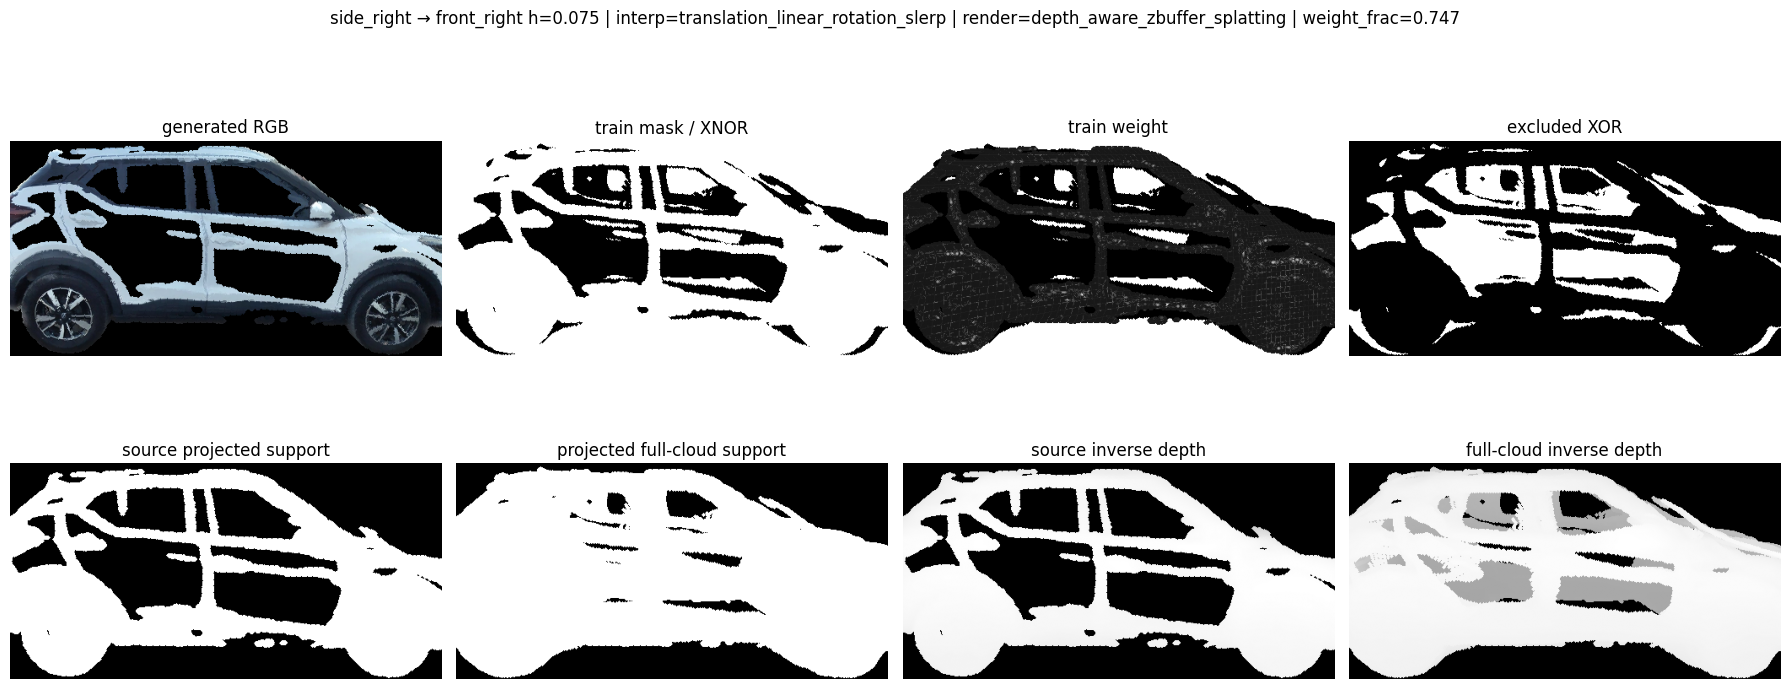

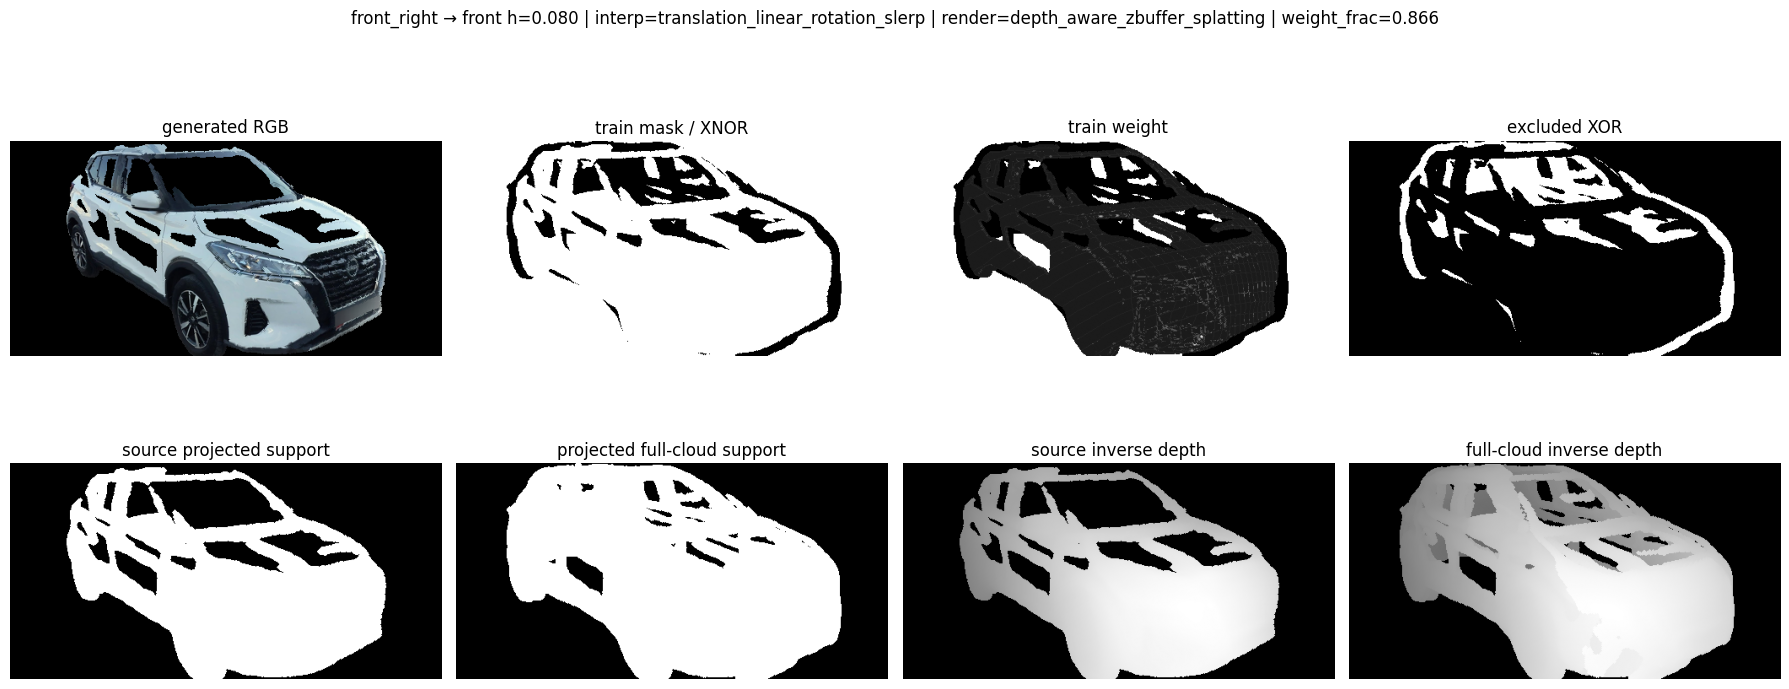

Saved diagnostics to: /content/drive/MyDrive/ResearchProject/dust3r_outputs_batch_strict_singlecar_method_v1/car_26004751/novel_views_brum_strict_v7_slerp_depth/visualizations


In [ ]:

records = json.loads(NOVEL_META.read_text())
sample_ids = np.linspace(0, len(records)-1, min(8, len(records))).round().astype(int)

for ridx in sample_ids:
    r = records[int(ridx)]
    img = np.asarray(Image.open(r['clean_image_path']).convert('RGB'))
    mask = np.asarray(Image.open(r['train_mask_path']).convert('L'))
    weight = np.asarray(Image.open(r['weight_path']).convert('L'))
    source_mask = np.asarray(Image.open(r['source_mask_path']).convert('L'))
    full_mask = np.asarray(Image.open(r['full_mask_path']).convert('L'))
    inconsistent = np.asarray(Image.open(r['inconsistent_mask_path']).convert('L'))

    # Depth maps are saved as .npy. Visualize inverse depth so nearer structures are brighter.
    source_depth = np.load(r['source_depth_path']) if 'source_depth_path' in r else None
    full_depth = np.load(r['full_depth_path']) if 'full_depth_path' in r else None
    if source_depth is not None:
        source_depth_vis = normalize01(np.where(np.isfinite(source_depth) & (source_depth > 0), 1.0 / np.maximum(source_depth, 1e-6), 0.0))
    else:
        source_depth_vis = np.zeros_like(mask, dtype=np.float32)
    if full_depth is not None:
        full_depth_vis = normalize01(np.where(np.isfinite(full_depth) & (full_depth > 0), 1.0 / np.maximum(full_depth, 1e-6), 0.0))
    else:
        full_depth_vis = np.zeros_like(mask, dtype=np.float32)

    overlay = img.copy()
    red = np.zeros_like(overlay); red[..., 0] = 255
    mb = mask > 0
    overlay[mb] = (0.65 * overlay[mb] + 0.35 * red[mb]).astype(np.uint8)

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.reshape(-1)
    axes[0].imshow(img); axes[0].set_title('generated RGB')
    axes[1].imshow(mask, cmap='gray'); axes[1].set_title('train mask / XNOR')
    axes[2].imshow(weight, cmap='gray'); axes[2].set_title('train weight')
    axes[3].imshow(inconsistent, cmap='gray'); axes[3].set_title('excluded XOR')
    axes[4].imshow(source_mask, cmap='gray'); axes[4].set_title('source projected support')
    axes[5].imshow(full_mask, cmap='gray'); axes[5].set_title('projected full-cloud support')
    axes[6].imshow(source_depth_vis, cmap='gray'); axes[6].set_title('source inverse depth')
    axes[7].imshow(full_depth_vis, cmap='gray'); axes[7].set_title('full-cloud inverse depth')
    for ax in axes: ax.axis('off')
    plt.suptitle(
        f"{r['source_view']} → {r['helper_view']} h={r['h']:.3f} | "
        f"interp={r.get('pose_interpolation','?')} | render={r.get('rendering_mode','?')} | "
        f"weight_frac={r['train_weight_frac']:.3f}"
    )
    plt.tight_layout()

    out_path = NOVEL_VIS_DIR / f"diagnostic_{int(ridx):03d}_{r['source_view']}_to_{r['helper_view']}_h{int(round(r['h']*1000)):03d}.png"
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

print('Saved diagnostics to:', NOVEL_VIS_DIR)


In [ ]:
# checker
df = pd.read_csv(NOVEL_CSV)
display(df)

summary = {
    'n_records': int(len(df)),
    'train_weight_frac_min': float(df['train_weight_frac'].min()),
    'train_weight_frac_mean': float(df['train_weight_frac'].mean()),
    'train_weight_frac_max': float(df['train_weight_frac'].max()),
    'inside_source_points_min': int(df['inside_source_points'].min()),
    'inside_full_points_min': int(df['inside_full_points'].min()),
    'manifest': str(NOVEL_META),
    'output_root': str(NOVEL_ROOT),
    'loss_requirement_for_4B': 'Generated views must use masked weighted L1 only; do not apply generated-view SSIM.',
    'pose_interpolation': POSE_INTERPOLATION_MODE,
    'rendering_mode': RENDERING_MODE,
    'depth_eps': float(DEPTH_EPS),
}
print(json.dumps(summary, indent=2))

assert summary['train_weight_frac_min'] >= 0.005
assert summary['inside_source_points_min'] > 500
assert summary['inside_full_points_min'] > 500

print('✅ 3A v7 complete: SLERP pose interpolation + depth-aware z-buffer splatting.')
print('Use NOVEL_META in 4B and enforce generated masked weighted L1, no generated SSIM.')

,source_view,helper_view,direction,h,inside_source_points,inside_full_points,train_mask_frac,train_weight_frac,mean_train_weight_positive
0,front,front_right,prev,0.025,14823,302828,0.900864,0.900864,0.818976
1,front,front_right,prev,0.050,14823,302828,0.899498,0.899498,0.815281
2,front,front_right,prev,0.075,14823,302828,0.897827,0.897827,0.817208
3,front,front_right,prev,0.080,14823,302828,0.897514,0.897514,0.810471
4,front,front_left,next,0.025,14823,302828,0.900047,0.900047,0.820406
...,...,...,...,...,...,...,...,...,...
59,front_right,side_right,prev,0.080,42726,302149,0.853340,0.853340,0.519009
60,front_right,front,next,0.025,43097,302785,0.867081,0.867081,0.578011
61,front_right,front,next,0.050,43074,302748,0.866760,0.866760,0.576585
62,front_right,front,next,0.075,43046,302690,0.866501,0.866501,0.595309


{
  "n_records": 64,
  "train_weight_frac_min": 0.7116241455078125,
  "train_weight_frac_mean": 0.8438024520874023,
  "train_weight_frac_max": 0.9634780883789062,
  "inside_source_points_min": 14823,
  "inside_full_points_min": 243494,
  "manifest": "/content/drive/MyDrive/ResearchProject/dust3r_outputs_batch_strict_singlecar_method_v1/car_26004751/novel_views_brum_strict_v7_slerp_depth/novel_views_manifest.json",
  "output_root": "/content/drive/MyDrive/ResearchProject/dust3r_outputs_batch_strict_singlecar_method_v1/car_26004751/novel_views_brum_strict_v7_slerp_depth",
  "loss_requirement_for_4B": "Generated views must use masked weighted L1 only; do not apply generated-view SSIM.",
  "pose_interpolation": "translation_linear_rotation_slerp",
  "rendering_mode": "depth_aware_zbuffer_splatting",
  "depth_eps": 1e-05
}
✅ 3A v7 complete: SLERP pose interpolation + depth-aware z-buffer splatting.
Use NOVEL_META in 4B and enforce generated masked weighted L1, no generated SSIM.
